## Dataset Load aur Exploration

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset load karein
# df = pd.read_csv(r'F:\DATA SCIENCE INTERNSHIP\Data-Science-Analytics-Internship\Task 01 - Term Deposit Subscription Prediction (Bank Marketing)\bank+marketing\bank\bank-full.csv', sep=';')
df = pd.read_csv(r'/content/bank-full.csv', sep=';')

# Pehle 5 rows dekhein
print(df.head())

# Missing values check karein
print(df.isnull().sum())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan  

data is already cleaned

## Feature Encoding

Label Encoding: Target variable (y) .

One-Hot Encoding: Rest features (x).

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Target variable 'y' (yes/no) ko 1/0 mein convert karein
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

# Baqi categorical variables ko dummy variables mein badlein
df_final = pd.get_dummies(df, drop_first=True)
# Final dataset dekhein
print(df_final.head())

   age  balance  day  duration  campaign  pdays  previous  y  job_blue-collar  \
0   58     2143    5       261         1     -1         0  0            False   
1   44       29    5       151         1     -1         0  0            False   
2   33        2    5        76         1     -1         0  0            False   
3   47     1506    5        92         1     -1         0  0             True   
4   33        1    5       198         1     -1         0  0            False   

   job_entrepreneur  ...  month_jul  month_jun  month_mar  month_may  \
0             False  ...      False      False      False       True   
1             False  ...      False      False      False       True   
2              True  ...      False      False      False       True   
3             False  ...      False      False      False       True   
4             False  ...      False      False      False       True   

   month_nov  month_oct  month_sep  poutcome_other  poutcome_success  \
0      F

## Model Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Features aur Target split karein
X = df_final.drop('y', axis=1)
y = df_final['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy check karein
from sklearn.metrics import accuracy_score, classification_report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9047882339931439
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.67      0.41      0.51      1091

    accuracy                           0.90      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043



## Model Evaluation

- **Confusion Matrix:** Batata hai ke kitne "Yes" sahi predict hue aur kitne ghalat.

- **F1-Score:** Precision aur Recall ka balance hai.

- **ROC Curve:** Model ki distinguishing ability dikhata hai.

Confusion Matrix:
 [[7738  214]
 [ 647  444]]
F1 Score: 0.5077186963979416


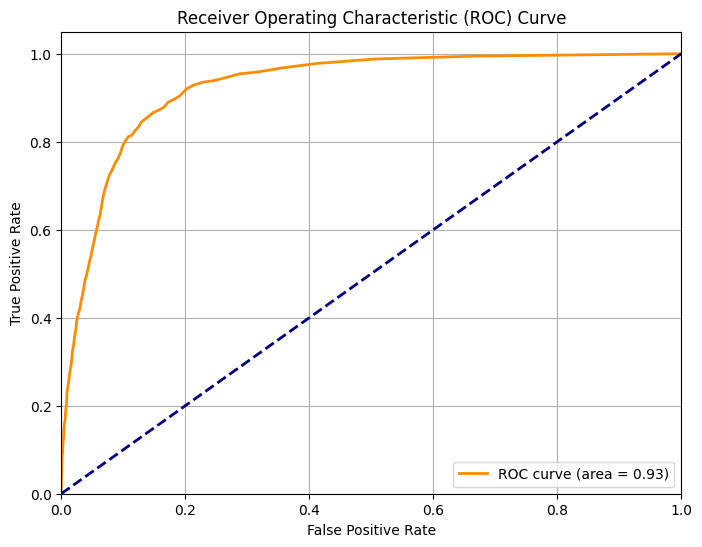

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# ROC Curve plot karne ke liye
probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Model Interpretability (SHAP)

In [ ]:
!pip install shap

XAI (Explainable AI) ka maqsad ye batana hai ke model ne koi faisla kyun kiya. SHAP values har feature ka impact dikhati hain.

Displaying Summary Plot for 5 predictions:


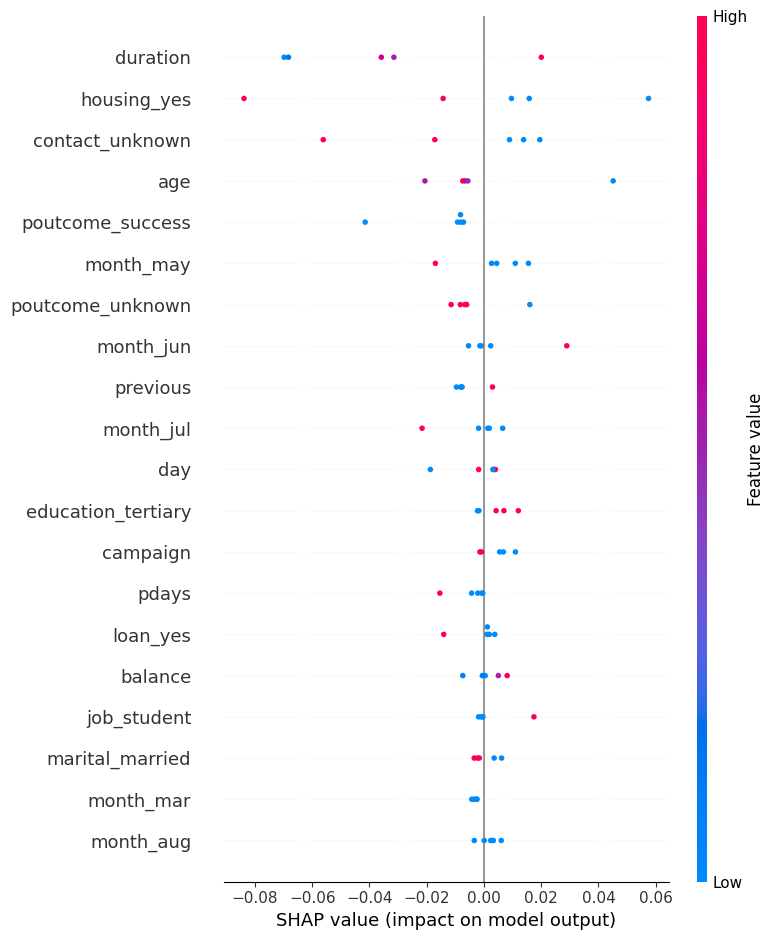

Displaying Waterfall Plot for prediction #1:


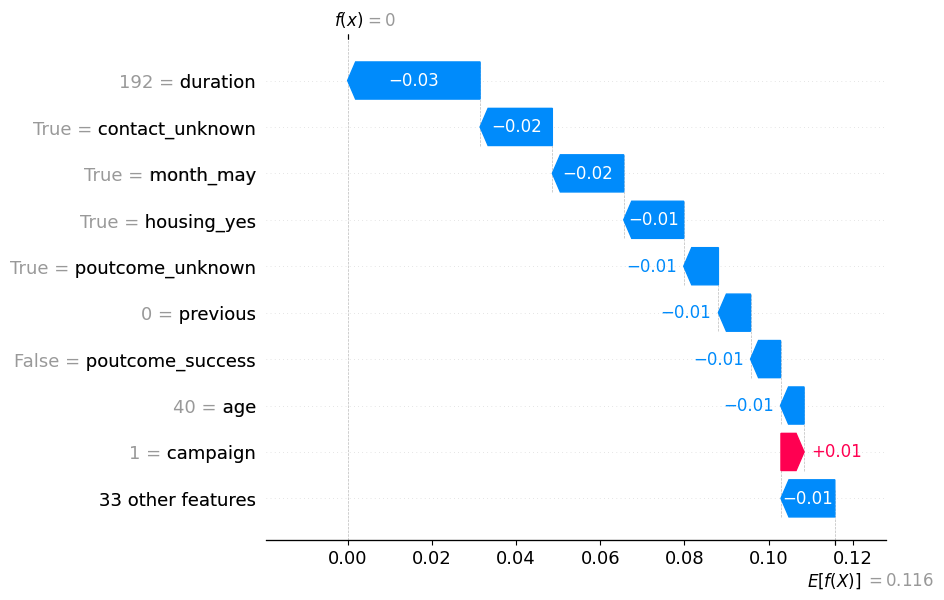

Displaying Waterfall Plot for prediction #2:


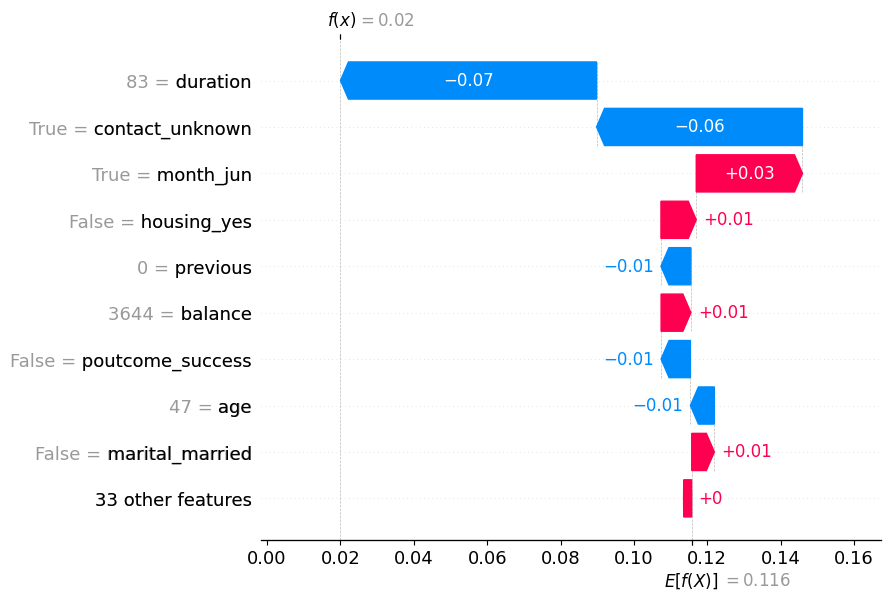

Displaying Waterfall Plot for prediction #3:


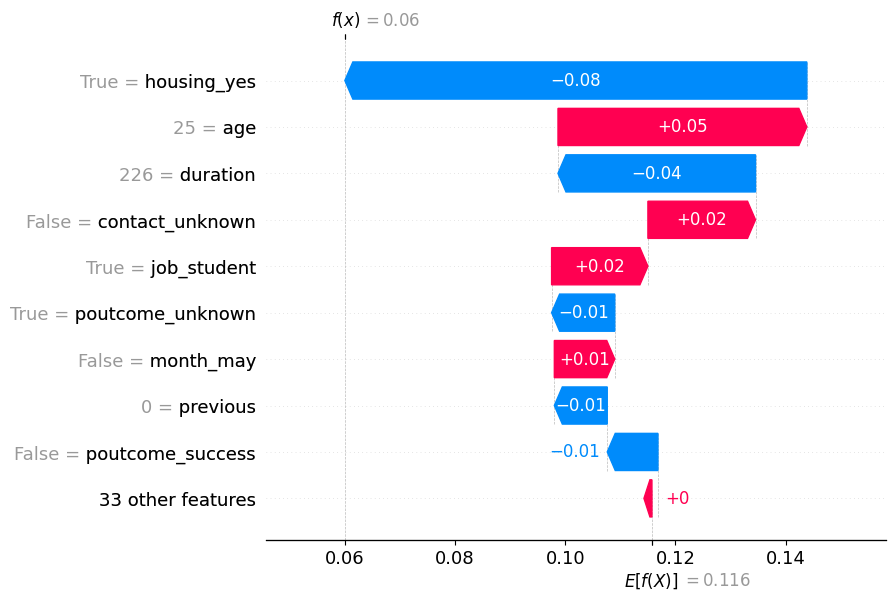

Displaying Waterfall Plot for prediction #4:


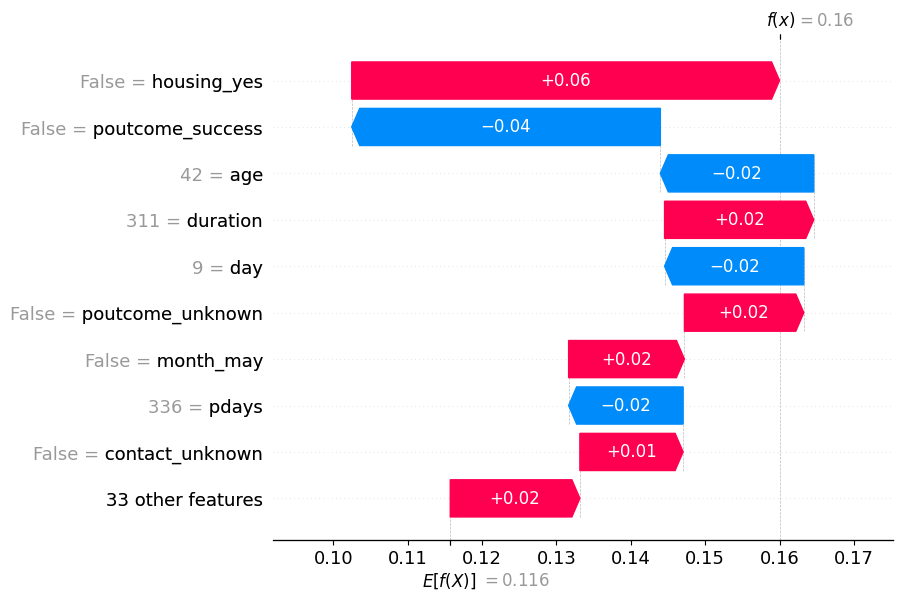

Displaying Waterfall Plot for prediction #5:


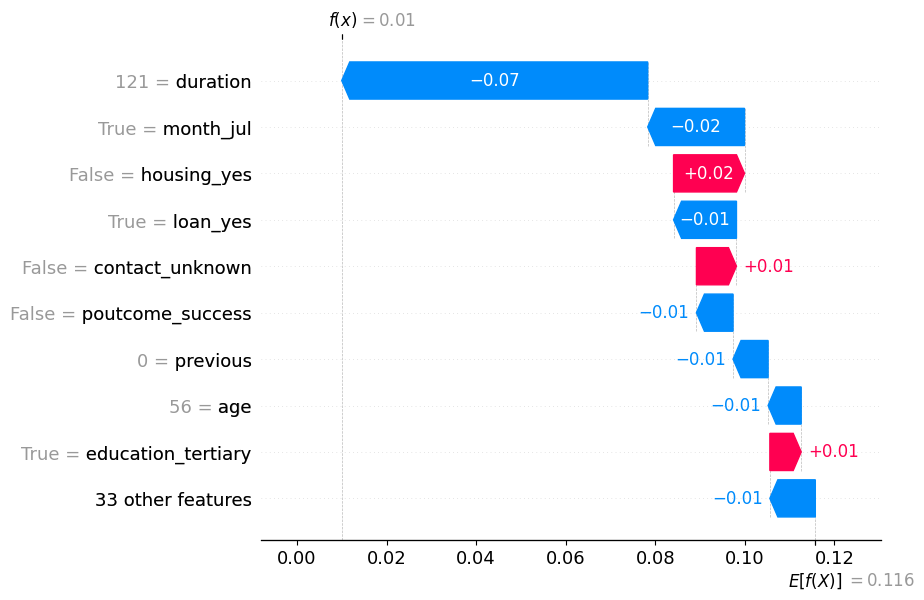

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Explainer initialization
explainer = shap.TreeExplainer(rf_model)

# 2. Only 5 predictions as requested
X_test_5 = X_test.iloc[:5, :]

# 3. Calculate SHAP values for these 5 samples
shap_values_5 = explainer(X_test_5)

# Handle binary classification output structure
if len(shap_values_5.shape) == 3:
    shap_values_class1 = shap_values_5[:, :, 1]
else:
    shap_values_class1 = shap_values_5

# 4. Summary Plot for these 5 predictions
print('Displaying Summary Plot for 5 predictions:')
shap.summary_plot(shap_values_class1, X_test_5, show=False)
plt.show()

# 5. Waterfall Plots for each of the 5 predictions
for i in range(5):
    print(f'Displaying Waterfall Plot for prediction #{i+1}:')
    shap.plots.waterfall(shap_values_class1[i])

In [ ]:
import shap

# 1. SHAP Explainer create karein
explainer = shap.TreeExplainer(rf_model)

# 2. Pehle 5 rows select karein (speed aur accuracy ke liye)
X_test_5 = X_test.iloc[:5, :]

# 3. Sirf in 5 predictions ke liye SHAP values calculate karein
# Class 1 (yes) ke liye shap_values nikaalein
shap_values = explainer.shap_values(X_test_5)

# 4. JavaScript plots initialize karein
shap.initjs()

# 5. Force plot for these 5 predictions
print('Displaying Force Plot for 5 predictions:')
display(shap.force_plot(explainer.expected_value[1], shap_values[1], X_test_5))

# 6. Summary plot for these 5 predictions
print('Displaying Summary Plot for 5 predictions:')
shap.summary_plot(shap_values[1], X_test_5)